---
# <div style="text-align: center"> Introduction </div>
---

Along these tutorials, we will see how <span style="color:blue">**SCOPE**</span> interacts with the different parts of the code to handle the execution of computational workflows. 

These are the topics covered in each tutorial:
1) The **System** class and its sources: the **Specie**, **Cell** and **Atom** classes  
2) The Computational workflow: **Branch**, **Workflow**, **Job**, and **Computation** classes  
3) The **State** class  
4) The **Data**, **Collection** and **VNM** classes
5) The **Input_data** class, and **scope input files**
6) Running <span style="color:blue">**SCOPE**</span> - Part 1: File Structure
7) Running <span style="color:blue">**SCOPE**</span> - Part 2: Execution 
8) Running <span style="color:blue">**SCOPE**</span> - Part 3: Detailed Actions
9) The Azo add-on: Subclasses, Analysis and Creation of Azo Systems

---
# <div style="text-align: center"> Tutorial 3: The State class</div>
---

In this tutorial, we will discuss the **State** class. A **State** is a 'picture' of a given **Source** during the execution of the computational Workflow. The main purpose of a **State** is to store the initial data for **Computations**, which have the ability to create a new state upon completion, or to update an existing one, depending on the user choices. 

Below, we will discuss how the **State** function works exactly, and how it connects **Species** (and **Cells**) with the computational workflow.  

In [1]:
import os
import scope
import numpy as np

In [2]:
## Path of the data folder. It should be "os.path.abspath('.')+'/Data"
data_folder = os.path.abspath('../')+'/Data/1-Tutorial_1/'

## Loads the System object from a binary file, provided in the tutorial folder
sys = scope.load_binary(f"{data_folder}/Systems/ABITEM/ABITEM.npy")

## This will set the main path of the system to the data folder, so that any new file created by SCOPE will be created in that folder.
sys.set_main_path(data_folder)

[14:00:11] Depickling from a version number (16.3)that is higher than our version (16.2).
This probably won't work.
[14:00:11] Depickling from a version number (16.3)that is higher than our version (16.2).
This probably won't work.
[14:00:11] Depickling from a version number (16.3)that is higher than our version (16.2).
This probably won't work.
[14:00:11] Depickling from a version number (16.3)that is higher than our version (16.2).
This probably won't work.
[14:00:11] Depickling from a version number (16.3)that is higher than our version (16.2).
This probably won't work.
[14:00:11] Depickling from a version number (16.3)that is higher than our version (16.2).
This probably won't work.
[14:00:11] Depickling from a version number (16.3)that is higher than our version (16.2).
This probably won't work.
[14:00:11] Depickling from a version number (16.3)that is higher than our version (16.2).
This probably won't work.
[14:00:11] Depickling from a version number (16.3)that is higher than ou

True

In [3]:
## All objects in SCOPE have a __repr__ method, so printing shows a summary of the object
print(sys)

-------------------------------------
-- >>> SCOPE System_sco Object >>> --
-------------------------------------
 Version               = 1.0
 Type                  = system
 Subtype               = sco_system
 Source Path           = /Users/sergivela/Documents/SCOPE/Program/Scope_Tutorials/Data/1-Tutorial_1/Sources/ABITEM/
 System File Path      = /Users/sergivela/Documents/SCOPE/Program/Scope_Tutorials/Data/1-Tutorial_1/Systems/ABITEM/
 System File Name      = /Users/sergivela/Documents/SCOPE/Program/Scope_Tutorials/Data/1-Tutorial_1/Systems/ABITEM/ABITEM.npy
 Computations Path     = /Users/sergivela/Documents/SCOPE/Program/Scope_Tutorials/Data/1-Tutorial_1/Computations/ABITEM/

 Num Sources           = 6
     idx: type, name, formula               
     0: cell, ABITEM01, H104-C92-N24-O4-S8-Fe4 
     1: cell, ABITEM, H104-C92-N24-O4-S8-Fe4 
     2: cell, ref_hs_cell, H104-C92-N24-O4-S8-Fe4 
     3: cell, ref_ls_cell, H104-C92-N24-O4-S8-Fe4 
     4: specie, ref_hs_mol, H18-C20-N6-S2

In [4]:
## Sources can be selected using the find_source function, and using the source name
found, source = sys.find_source("ref_hs_mol")
print(source)

-----------------------------------
------ SCOPE MOLECULE Object ------
-----------------------------------
 Version               = 1.0
 Type                  = specie
 Sub-Type              = molecule
 Name                  = ref_hs_mol
 Number of Atoms       = 47
 Formula               = H18-C20-N6-S2-Fe
 Charge                = 0
 Spin (alpha - beta)   = 4
 Number of Parents     = 1
 Has Adjacency Matrix  = YES
 Has Bonds             = YES

 Num of Ligands        = 3
   Ligand 0: C-N-S with 3 atoms. Smiles: [N-]=C=S
   Ligand 1: H18-C18-N4 with 40 atoms. Smiles: [H]c1nc(C([H])([H])N(C([H])([H])c2nc([H])c([H])c([H])c2[H])C([H])([H])c2nc([H])c([H])c([H])c2[H])c([H])c([H])c1[H]
   Ligand 2: C-N-S with 3 atoms. Smiles: [N-]=C=S

 Num of Metals         = 1
   Metal 0: Fe with charge:2 and spin:4




## States

In [5]:
## Sources have "STATES"
source.states

[--------------------------------
 ------ SCOPE STATE Object ------
 --------------------------------
  Name                  = initial
  Source Name           = ref_hs_mol
  Source Type           = specie
  Labels                = Fe...
  Coord                 = [3.7430176, 3.9944543, 13.5094621]...
  Number of Units (Z)   = 1
 
 
  Num of Molecules:     = 1
  With Formulae:                               
     0: H18-C20-N6-S2-Fe ,
 --------------------------------
 ------ SCOPE STATE Object ------
 --------------------------------
  Name                  = pbe_opt
  Source Name           = ref_hs_mol
  Source Type           = specie
  Labels                = Fe...
  Coord                 = [3.738143, 3.85153, 13.537435]...
  Number of Units (Z)   = 1
 
 
  Num of Molecules:     = 1
  With Formulae:                               
     0: H18-C20-N6-S2-Fe ,
 --------------------------------
 ------ SCOPE STATE Object ------
 --------------------------------
  Name                  = b3

In [6]:
## States are accessible directly from the list
initial_state = source.states[0]
## Or through the find_state function
found, initial_state = source.find_state("initial")
## As in other find functions, find_states returns: a boolean, and the actual State object
print(found)
print(initial_state)

True
--------------------------------
------ SCOPE STATE Object ------
--------------------------------
 Name                  = initial
 Source Name           = ref_hs_mol
 Source Type           = specie
 Labels                = Fe...
 Coord                 = [3.7430176, 3.9944543, 13.5094621]...
 Number of Units (Z)   = 1


 Num of Molecules:     = 1
 With Formulae:                               
    0: H18-C20-N6-S2-Fe 



In [7]:
## This is the "initial" state, and is automatically created when adding a source to a system with sys.add_source()
## Notice that the coordinates, for example, are just the same than those of the source
print(np.array_equal(source.coord, initial_state.coord))


True


In [8]:
## Computations take input information from states, and bring new output information to either (i) the same state, or (ii) a new state that is created.
## States store all computations that have modified them:
found, pbe_state = source.find_state("pbe_opt")
print(pbe_state.computations)

## Here, only one computation worked on the "initial" State, and stored its results on the "pbe_opt" State. 
## Notice Initial State and Final State attributes

[---------------------------------------------------
   >>> >>> >>> >>> COMPUTATION                     
---------------------------------------------------
 Source Type           = specie
 Source sub-Type       = molecule
 Branch Name           = isolated
 Workflow Name         = ref_hs_mol
 Job Name              = opt
 Job Type              = opt
---------------------------------------------------
 Initial State         = initial
 Final State           = pbe_opt
 Comp software         = g16
 Comp index            = 1
 Comp step             = 1
 Comp run_number       = 1
 Comp inp_path         = /Users/sergivela/Documents/SCOPE/Program/Scope_Tutorials/Data/1-Tutorial_1/Computations/ABITEM/isolated/ABITEM_ref_hs_mol_opt_r1.com
 Comp out_path         = /Users/sergivela/Documents/SCOPE/Program/Scope_Tutorials/Data/1-Tutorial_1/Computations/ABITEM/isolated/ABITEM_ref_hs_mol_opt_r1.log
 Comp isregistered     = True
 Comp isgood           = True
 Comp isfinished       = True
 Comp elapsed_t

In [9]:
## In this Computation, a DFT optimization with PBE was performed.
## Notice that the coordinates of the pbe_opt State are different.
print(source.coord[0])        ## The original coordinates
print(initial_state.coord[0]) ## The initial state coordinates, with the same geometry
print(pbe_state.coord[0])   ## The final state coordinates, with the optimized geometry

[3.7430176, 3.9944543, 13.5094621]
[3.7430176, 3.9944543, 13.5094621]
[3.738143, 3.85153, 13.537435]


In [10]:
## If multiple computations target the same final state, these keep updating it.

## For instance, when multiple optimization computations are necessary:
   ## Computation 1: Reads initial state (coordinates "A"), optimization runs, and last-step coordinates ("B") are used to create the final state.
   ## Computation 2: Reads set of coordinates "B", continues optimization, and last-step coordinates ("C") update the final state.
   ## ... This goes on until the final coordinates are considered good, or the optimization job stops.

### Why are States necessary?

In [11]:
## For two reasons:

In [12]:
# (1) When a computation finishes, the final information may be different than the that of the source. 
# For instance, a geometry optimization might break a bond, so the initial molecule is no longer the same. 

# Thus, if the user wants to get the molecules out of a STATEs coordinates, they need to be re-computed:
new_molec = pbe_state.get_molecules()[0]

## In most cases, the new molecule will have the same chemical composition than the original one (i.e. the source)
original_molec = source

## Notice that Species can be compared based on some compositional criteria (see specie class, function __eq__())
print(original_molec == new_molec)


True


In [13]:
# (2) Because it enables the user to store multiple results of the molecule (e.g. the energy, coordinates).
# for instance, multiple optimization jobs with different DFT functionals:
found, b3lyp_state = source.find_state("b3lyp_opt")
  
print(pbe_state.results)    # REMINDER: above, we defined pbe_state, as the state that results from a pbe optimization
print(b3lyp_state.results) 

{'energy': energy: -3158.67305783 au}
{'energy': energy: -3159.62579289 au}


In [14]:
# The b3lyp state loaded above contains the information of two computations...
print(len(b3lyp_state.computations))

# Associated with two different jobs, with names:
for comp in b3lyp_state.computations:
    print(comp._job.name)

2
opt2
freq


In [15]:
# The second one computes the vibrational normal modes, and stores them:
print(b3lyp_state.VNMs[0])  ## This is the first one

----------------------------------
------   SCOPE VNM Object    -----
----------------------------------
 Index                  = 1
 Freq (cm-1)            = 21.6469
 IR Intensity (KM/Mole) = 1.0847
 Reduced Mass (AMU)     = 14.2624
 Has Mode               = False



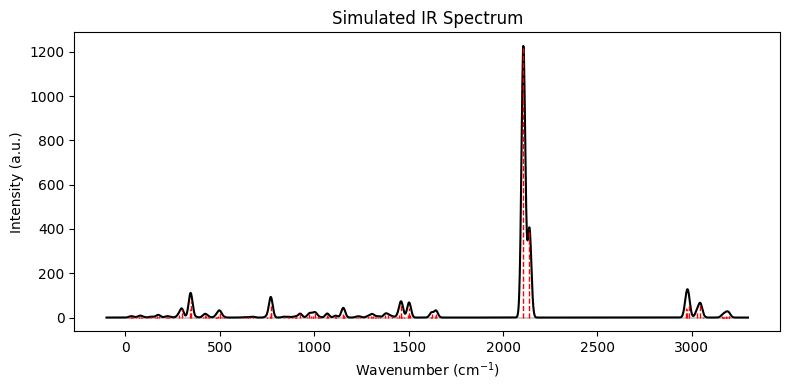

In [16]:
# And this is the resulting IR spectrum
b3lyp_state.plot_ir_spectrum()

### State Tools

We implemented in SCOPE some tools that might be useful in computational chemistry. 


#### Sampling Geometries

In [17]:
## For instance, the function state.sample_geometries() does a geometry sampling from the vibrational normal modes:

In [18]:
## By default, the eigenvectors (modes) are not stored in the VNM object. We need to read them. 
comp   = b3lyp_state.computations[-1]                               # Here, we select the computation were the frequencies were computed
output = comp.create_output()                                       # Here, we create the Output object. The Output class is what reads and parses the output file
vnms   = output.get_vnms(witheigen=True)                            # Here, we extract the VNM objects from the output, but now with the eigenvectors
b3lyp_state.set_VNMs(vnms)                                          # Here, we set the VNMs in the state, so they are stored and can be used by the sampling function    

In [19]:
# Here, 10 geometries are generated. The function returns the Q displacements, the coordinates, and the energies (harmonic oscillator) of the sampled geometries.
qdis, geom, ener = b3lyp_state.sample_geometries(10, n_fps_rounds=0, temp=300)

# The Sampling is performed using a normal distribution for each mode, with width determined by thermal fluctuations.
# Geometries that change the molecular connectivity are discarded, which is a safety check to avoid invalid geometries.
# Large unphysical displacements are also discarded. This breaks the expected energy distribution of the resulting geometries. (np.mean(energies) should approach ZPE/2) 

# The function may return fewer than `n_samples` geometries if the adjacency check fails frequently.
# When this happens, a warning is displayed

In [20]:
## One way to compute how different is one geometry from the original one, is to compute the maximum Q displacement:
import numpy as np
maxdisp = 0
for q in qdis: 
    if np.linalg.norm(q) > maxdisp: maxdisp = np.linalg.norm(q)
print(np.round(maxdisp,4))

4.3189


In [21]:
# To increase the sampling amplitude (i.e. the distance from the reference geometry), you can increase temperature:
qdis, geom, ener = b3lyp_state.sample_geometries(10, n_fps_rounds=0, temp=1000)

maxdisp = 0
for q in qdis: 
    if np.linalg.norm(q) > maxdisp: maxdisp = np.linalg.norm(q)
print(np.round(maxdisp,4))

5.3622


In [ ]:
## A better alternative is to perform different rounds of sampling, and select the furthest structures. 
## This is a slower method. It takes ca. 10 seconds in an M3 pro laptop. Uncomment to use

# qdis, geom, ener = b3lyp_state.sample_geometries(10, n_aux_geoms=20, n_fps_rounds=2, temp=300)
#
# maxdisp = 0
# for q in qdis: 
#     if np.linalg.norm(q) > maxdisp: maxdisp = np.linalg.norm(q)
# print(np.round(maxdisp,4))

## If this worked as expected, you should see that the maximum displacement is larger than in the previous cell, even if the temperature is lower.
## The second method is better for sampling purposes, but it can be slow. 

7.2814


---
## How to Parse QC Computations **Manually** and Store Results in a State
---

Normally, SCOPE parses and manages the results of computations that are created by the computational workflow.  
However, if you're an advanced user, you might want to update some of these results, or just import some information to SCOPE without having it dealing with the job.

Here, we'll see how we can parse data from a Gaussian16 computation (as an example), and store its results in a state
Parts of what is shown here has been discussed above, already. Notably, the Output class

In [24]:
## We should have in memory the b3lyp_state we discussed before. Let's select the optimization computation associated with it:
comp        = b3lyp_state.computations[-2]    

## We get the path:
comp_file   = comp.out_path

## This would be the path of a Gaussian output file that we have. The lines above were just to get the path of one such file as an example.  
print(comp_file)

/Users/sergivela/Documents/SCOPE/Program/Scope_Tutorials/Data/1-Tutorial_1/Computations/ABITEM/isolated/ABITEM_ref_hs_mol_opt2_r1.log


In [25]:
## Parsing computations manually, implies creating an Output object of the corresponding software. In this case, Gaussian 16.
lines  = scope.parse_general.read_lines_file(comp_file)      # First, we read the lines
output = scope.software.gaussian.G16_output(lines)           # Then, we create the output

G16_OUTPUT: output created without Computation.
G16_OUTPUT: Please specify comp_type doing set_comp_type()
G16_OUTPUT: Options are: 'scf', 'opt', 'freq', 'td' and 'tda'


In [26]:
## Since we're doing this manually, the Output is not associated to a Computation. Thus, we need to specify which type of job is associated with it:
output.set_comp_type('opt')


In [27]:
## From here, you can extract energies ...
energy = output.get_last_energy()
print(energy)

-3159.62579289


In [28]:
## ... and final geometry
labels, coords = output.get_last_geometry(debug=1)
print(labels[0], coords[0])

Fe [3.774774, 3.779086, 13.494815]


In [29]:
## You can use this data to update the state, if you want. For instance:
b3lyp_state.set_energy(energy, 'au')
b3lyp_state.set_geometry(labels, coords)

In [30]:
## The functions that take care of that in SCOPE are in scope.register_data. You can have a look at them for more details. 

In [31]:
## Remember that, if you update the systems, sources, or states information manually, you need to save them again in a binary file, if you want to keep the changes.
## Just do:
#sys.save() to save in the default path = sys.system_file
## or 
#sys.save("whatever_path") if you want to specify the actual path